**M38 Parte1**

**M38 PArte1**

**M38 Parte1**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Configurações de estilo
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print('Bibliotecas carregadas com sucesso!')
print(f'Pandas  : {pd.__version__}')
print(f'NumPy   : {np.__version__}')
print(f'Seaborn : {sns.__version__}')

Bibliotecas carregadas com sucesso!
Pandas  : 2.2.2
NumPy   : 2.0.2
Seaborn : 0.13.2


Arquivo 'credit_scoring (5).ftr' carregado com sucesso.
--- Primeiras Linhas do Dataset ---
    data_ref  index sexo posse_de_veiculo posse_de_imovel  qtd_filhos  \
0 2015-01-01   5733    F                N               N           0   
1 2015-01-01    727    F                S               S           0   
2 2015-01-01   6374    F                N               N           2   
3 2015-01-01   9566    F                N               N           0   
4 2015-01-01   9502    F                S               N           0   

    tipo_renda             educacao estado_civil tipo_residencia  idade  \
0   Empresário                Médio     Solteiro            Casa     43   
1  Assalariado                Médio       Casado            Casa     35   
2  Assalariado                Médio       Casado            Casa     31   
3  Assalariado                Médio       Casado            Casa     54   
4  Assalariado  Superior incompleto     Solteiro            Casa     31   

   tempo_emprego  

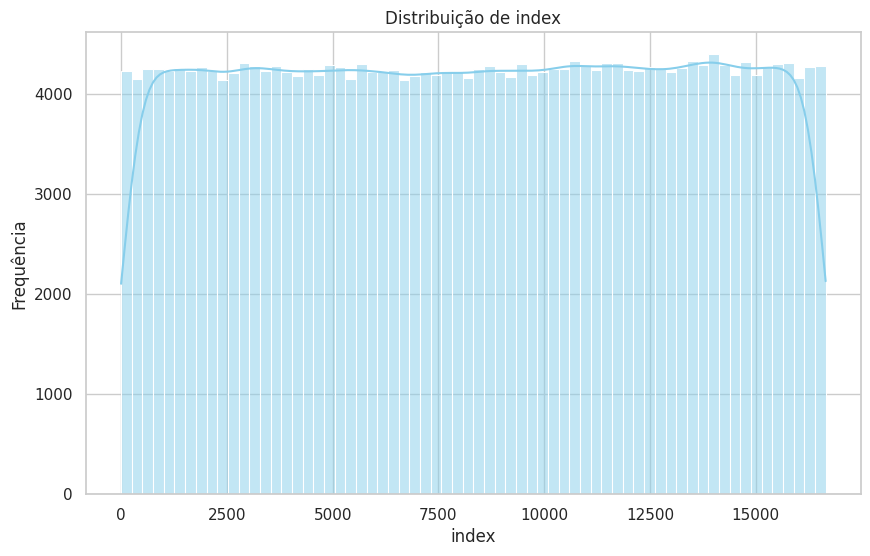

/tmp/ipykernel_2222/477310927.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')


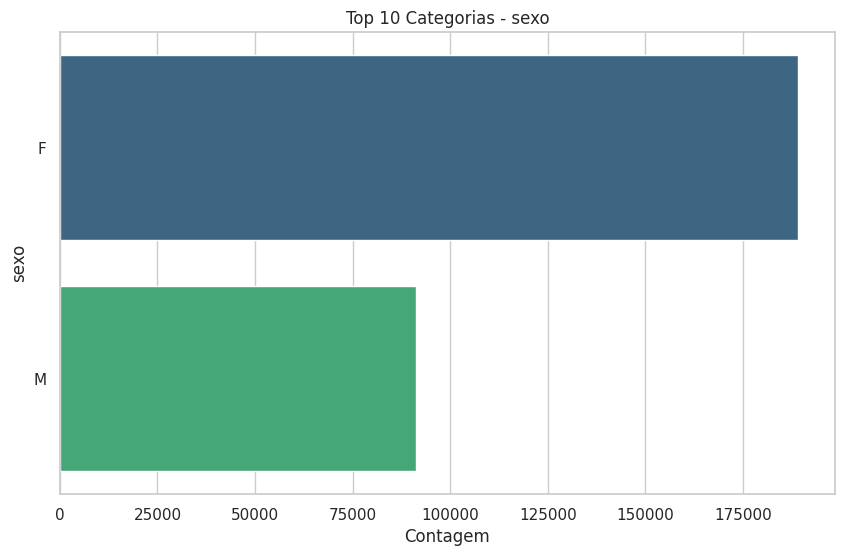

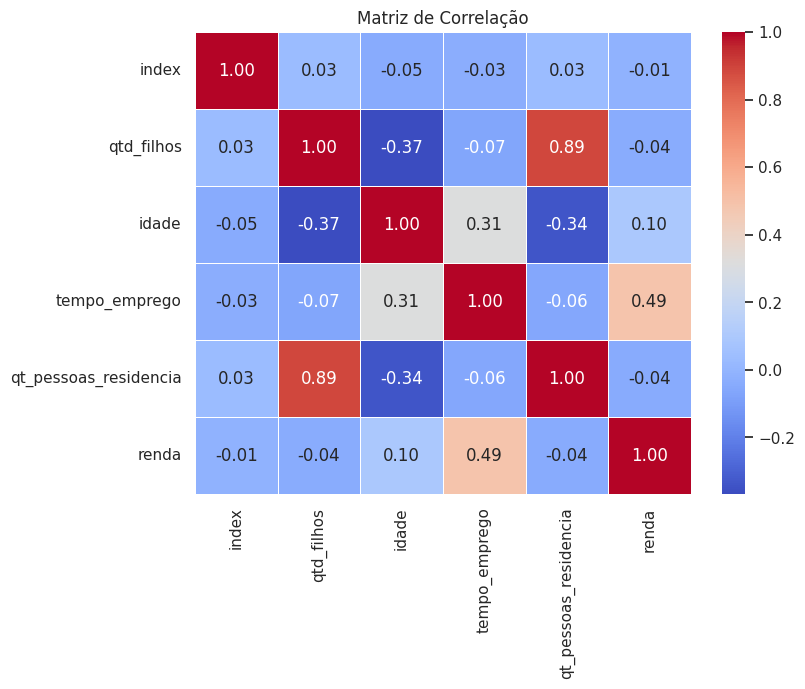

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. CARREGAMENTO DOS DADOS
# Caso o arquivo seja uma planilha Excel (.xlsx), primeiro listamos as abas
try:
    # Use the feather file found in the environment
    df = pd.read_feather("/content/credit_scoring (5).ftr")
    print("Arquivo 'credit_scoring (5).ftr' carregado com sucesso.")
except FileNotFoundError:
    # Caso seja um arquivo CSV, descomente a linha abaixo:
    # df = pd.read_csv("seu_arquivo.csv")
    print("Arquivo não encontrado. Certifique-se do caminho correto.")
except Exception as e:
    print(f"Ocorreu um erro ao carregar o arquivo: {e}")

# 2. ANÁLISE EXPLORATÓRIA E SUMARIZAÇÃO
# Only proceed if df was successfully loaded
if 'df' in locals():
    print("--- Primeiras Linhas do Dataset ---")
    print(df.head())

    print("\n--- Informações Gerais ---")
    print(df.info())

    print("\n--- Estatísticas Descritivas (Variáveis Numéricas) ---")
    print(df.describe())

    print("\n--- Valores Ausentes por Coluna ---")
    print(df.isnull().sum())

    # 3. LIMPEZA DE DADOS (Exemplo básico)
    # Remove duplicatas
    df = df.drop_duplicates()

    # 4. VISUALIZAÇÃO DE DADOS
    # Identificando colunas numéricas e categóricas para gerar gráficos automáticos
    num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

    # Gráfico 1: Distribuição da primeira variável numérica (Histograma)
    if num_cols:
        plt.figure()
        sns.histplot(df[num_cols[0]], kde=True, color='skyblue')
        plt.title(f'Distribuição de {num_cols[0]}')
        plt.xlabel(num_cols[0])
        plt.ylabel('Frequência')
        plt.savefig('distribuicao_numerica.png', dpi=300, bbox_inches='tight')
        plt.show()

    # Gráfico 2: Contagem da primeira variável categórica (Gráfico de Barras)
    if cat_cols:
        plt.figure()
        # Limitando às 10 categorias mais frequentes para não poluir o gráfico
        top_categories = df[cat_cols[0]].value_counts().head(10)
        sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')
        plt.title(f'Top 10 Categorias - {cat_cols[0]}')
        plt.xlabel('Contagem')
        plt.ylabel(cat_cols[0])
        plt.savefig('contagem_categorica.png', dpi=300, bbox_inches='tight')
        plt.show()

    # Gráfico 3: Correlação entre variáveis numéricas (Heatmap)
    if len(num_cols) > 1:
        plt.figure(figsize=(8, 6))
        sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
        plt.title('Matriz de Correlação')
        plt.savefig('matriz_correlacao.png', dpi=300, bbox_inches='tight')
        plt.show()

In [ ]:
# Carregando o dataset
df = sns.load_dataset('tips')

print(f'Shape do dataset: {df.shape[0]} linhas × {df.shape[1]} colunas')
print('\nPrimeiras 5 linhas:')
df.head()

Shape do dataset: 244 linhas × 7 colunas

Primeiras 5 linhas:


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
# Informações gerais sobre tipos e missings
print('=== Informações do Dataset ===')
df.info()
print('\nValores ausentes por coluna:')
print(df.isnull().sum())

=== Informações do Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB

Valores ausentes por coluna:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


In [ ]:
# Estatísticas descritivas gerais
print('=== Estatísticas Descritivas — Variáveis Numéricas ===')
df.describe().round(2)

=== Estatísticas Descritivas — Variáveis Numéricas ===


,total_bill,tip,size
count,244.00,244.00,244.00
mean,19.79,3.00,2.57
std,8.90,1.38,0.95
min,3.07,1.00,1.00
25%,13.35,2.00,2.00
50%,17.80,2.90,2.00
75%,24.13,3.56,3.00
max,50.81,10.00,6.00


Tabela de frequência

In [ ]:
# Função auxiliar para tabela de frequência formatada
def tabela_frequencia(serie, nome_variavel):
    freq_abs  = serie.value_counts()
    freq_rel  = serie.value_counts(normalize=True).mul(100).round(2)
    freq_acum = freq_rel.cumsum().round(2)

    tabela = pd.DataFrame({
        'Frequência Absoluta': freq_abs,
        'Frequência Relativa (%)': freq_rel,
        'Frequência Acumulada (%)': freq_acum
    })
    tabela.index.name = nome_variavel
    return tabela

# Variáveis categóricas
variaveis_cat = ['sex', 'smoker', 'day', 'time']

for var in variaveis_cat:
    print(f'\n{'='*55}')
    print(f'  Tabela de Frequência — {var.upper()}')
    print(f'{'='*55}')
    display(tabela_frequencia(df[var], var))


  Tabela de Frequência — SEX


,Frequência Absoluta,Frequência Relativa (%),Frequência Acumulada (%)
sex,,,
Male,157,64.34,64.34
Female,87,35.66,100.00



  Tabela de Frequência — SMOKER


,Frequência Absoluta,Frequência Relativa (%),Frequência Acumulada (%)
smoker,,,
No,151,61.89,61.89
Yes,93,38.11,100.00



  Tabela de Frequência — DAY


,Frequência Absoluta,Frequência Relativa (%),Frequência Acumulada (%)
day,,,
Sat,87,35.66,35.66
Sun,76,31.15,66.81
Thur,62,25.41,92.22
Fri,19,7.79,100.01



  Tabela de Frequência — TIME


,Frequência Absoluta,Frequência Relativa (%),Frequência Acumulada (%)
time,,,
Dinner,176,72.13,72.13
Lunch,68,27.87,100.00


TAbela Cruzada

In [ ]:
# Tabela cruzada: sexo × dia da semana
print('=== Tabela Cruzada: Sexo × Dia da Semana (contagem) ===')
ct1 = pd.crosstab(df['sex'], df['day'], margins=True, margins_name='Total')
display(ct1)

print('\n=== Tabela Cruzada: Sexo × Dia da Semana (proporção por linha, %) ===')
ct1_pct = pd.crosstab(df['sex'], df['day'], normalize='index').mul(100).round(2)
display(ct1_pct)

=== Tabela Cruzada: Sexo × Dia da Semana (contagem) ===


day,Thur,Fri,Sat,Sun,Total
sex,,,,,
Male,30,10,59,58,157
Female,32,9,28,18,87
Total,62,19,87,76,244



=== Tabela Cruzada: Sexo × Dia da Semana (proporção por linha, %) ===


day,Thur,Fri,Sat,Sun
sex,,,,
Male,19.11,6.37,37.58,36.94
Female,36.78,10.34,32.18,20.69


In [ ]:
# Tabela cruzada: fumante × período (Lunch/Dinner)
print('=== Tabela Cruzada: Fumante × Período (contagem) ===')
ct2 = pd.crosstab(df['smoker'], df['time'], margins=True, margins_name='Total')
display(ct2)

print('\n=== Tabela Cruzada: Fumante × Período (proporção por coluna, %) ===')
ct2_pct = pd.crosstab(df['smoker'], df['time'], normalize='columns').mul(100).round(2)
display(ct2_pct)

=== Tabela Cruzada: Fumante × Período (contagem) ===


time,Lunch,Dinner,Total
smoker,,,
Yes,23,70,93
No,45,106,151
Total,68,176,244



=== Tabela Cruzada: Fumante × Período (proporção por coluna, %) ===


time,Lunch,Dinner
smoker,,
Yes,33.82,39.77
No,66.18,60.23


In [ ]:
# Tabela cruzada com valor médio (gorjeta média por sexo e dia)
print('=== Gorjeta Média (USD) por Sexo e Dia da Semana ===')
pivot_tip = df.pivot_table(
    values='tip',
    index='sex',
    columns='day',
    aggfunc='mean'
).round(2)
display(pivot_tip)

=== Gorjeta Média (USD) por Sexo e Dia da Semana ===


day,Thur,Fri,Sat,Sun
sex,,,,
Male,2.98,2.69,3.08,3.22
Female,2.58,2.78,2.80,3.37


Estatística descritiva por grupo

In [ ]:
# Descritivas de total_bill e tip agrupadas por dia
print('=== Estatísticas de total_bill e tip por Dia da Semana ===')
desc_dia = df.groupby('day')[['total_bill', 'tip']].agg(
    ['mean', 'median', 'std', 'min', 'max', 'count']
).round(2)
display(desc_dia)

=== Estatísticas de total_bill e tip por Dia da Semana ===


total_bill                                   tip                     \
           mean median   std   min    max count  mean median   std   min   
day                                                                        
Thur      17.68  16.20  7.89  7.51  43.11    62  2.77   2.30  1.24  1.25   
Fri       17.15  15.38  8.30  5.75  40.17    19  2.73   3.00  1.02  1.00   
Sat       20.44  18.24  9.48  3.07  50.81    87  2.99   2.75  1.63  1.00   
Sun       21.41  19.63  8.83  7.25  48.17    76  3.26   3.15  1.23  1.01   

                   
        max count  
day                
Thur   6.70    62  
Fri    4.73    19  
Sat   10.00    87  
Sun    6.50    76

In [ ]:
# Criando variável: percentual de gorjeta sobre a conta total
df['pct_gorjeta'] = (df['tip'] / df['total_bill'] * 100).round(2)

print('=== Percentual de Gorjeta sobre a Conta (%) ===')
print(df['pct_gorjeta'].describe().round(2))
print(f'\nPercentual médio de gorjeta: {df["pct_gorjeta"].mean():.2f}%')
print(f'Percentual mediano de gorjeta: {df["pct_gorjeta"].median():.2f}%')

=== Percentual de Gorjeta sobre a Conta (%) ===
count    244.00
mean      16.08
std        6.11
min        3.56
25%       12.91
50%       15.48
75%       19.15
max       71.03
Name: pct_gorjeta, dtype: float64

Percentual médio de gorjeta: 16.08%
Percentual mediano de gorjeta: 15.47%


visualizações gráficas

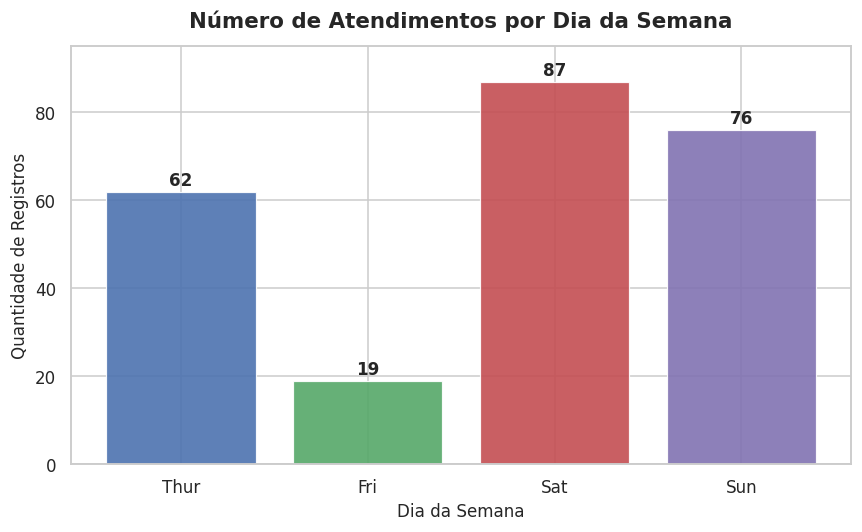

In [ ]:
contagem_dia = df['day'].value_counts().reindex(['Thur', 'Fri', 'Sat', 'Sun'])

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    contagem_dia.index,
    contagem_dia.values,
    color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'],
    edgecolor='white',
    linewidth=0.8,
    alpha=0.9
)

# Adicionar rótulos nas barras
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f'{int(height)}',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.set_title('Número de Atendimentos por Dia da Semana', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Dia da Semana')
ax.set_ylabel('Quantidade de Registros')
ax.set_ylim(0, contagem_dia.max() + 8)
plt.tight_layout()
plt.show()

gráfico de pizza

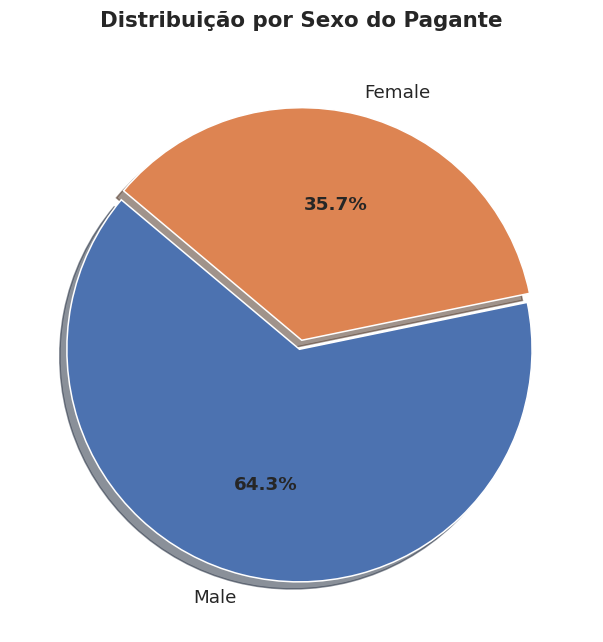


Distribuição por sexo:
        Frequência Absoluta  Frequência Relativa (%)  Frequência Acumulada (%)
sex                                                                           
Male                    157                    64.34                     64.34
Female                   87                    35.66                    100.00


In [ ]:
contagem_sexo = df['sex'].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    contagem_sexo.values,
    labels=contagem_sexo.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['#4C72B0', '#DD8452'],
    explode=(0.04, 0),
    shadow=True,
    textprops={'fontsize': 12}
)

for autotext in autotexts:
    autotext.set_fontweight('bold')

ax.set_title('Distribuição por Sexo do Pagante', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print('\nDistribuição por sexo:')
print(tabela_frequencia(df['sex'], 'sex'))

histograma

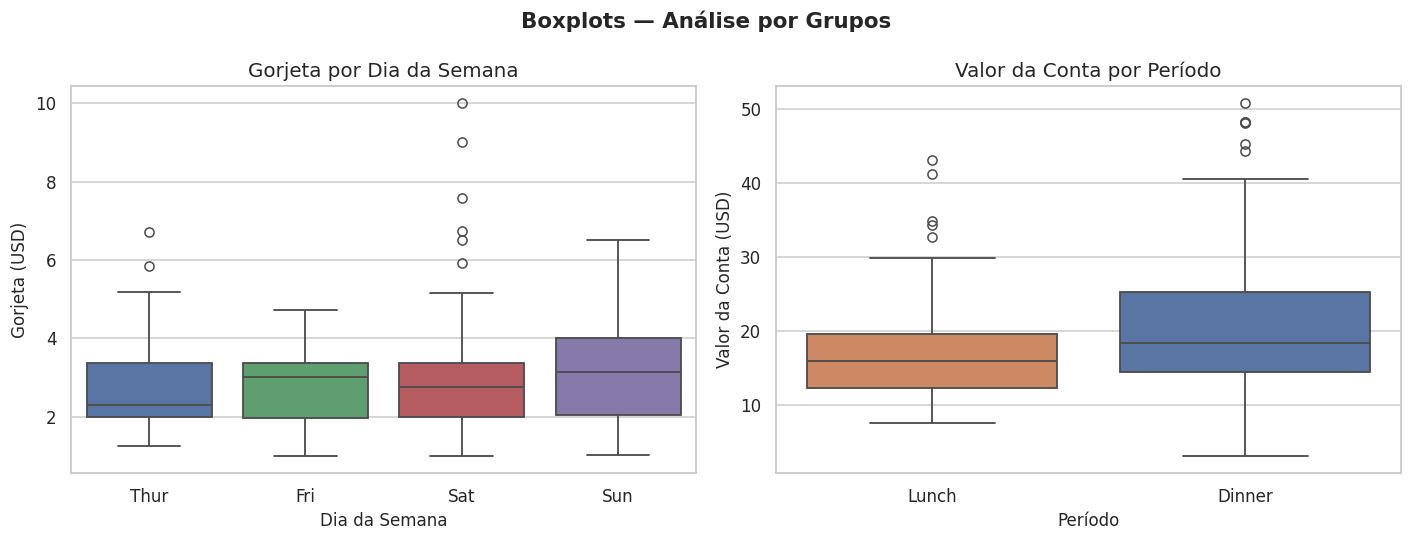

In [ ]:
ordem_dias = ['Thur', 'Fri', 'Sat', 'Sun']
paleta     = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot: gorjeta por dia
sns.boxplot(
    data=df, x='day', y='tip',
    order=ordem_dias, palette=paleta,
    ax=axes[0], linewidth=1.2
)
axes[0].set_title('Gorjeta por Dia da Semana')
axes[0].set_xlabel('Dia da Semana')
axes[0].set_ylabel('Gorjeta (USD)')

# Boxplot: valor da conta por período
sns.boxplot(
    data=df, x='time', y='total_bill',
    palette=['#DD8452', '#4C72B0'],
    ax=axes[1], linewidth=1.2
)
axes[1].set_title('Valor da Conta por Período')
axes[1].set_xlabel('Período')
axes[1].set_ylabel('Valor da Conta (USD)')

fig.suptitle('Boxplots — Análise por Grupos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

boxplot

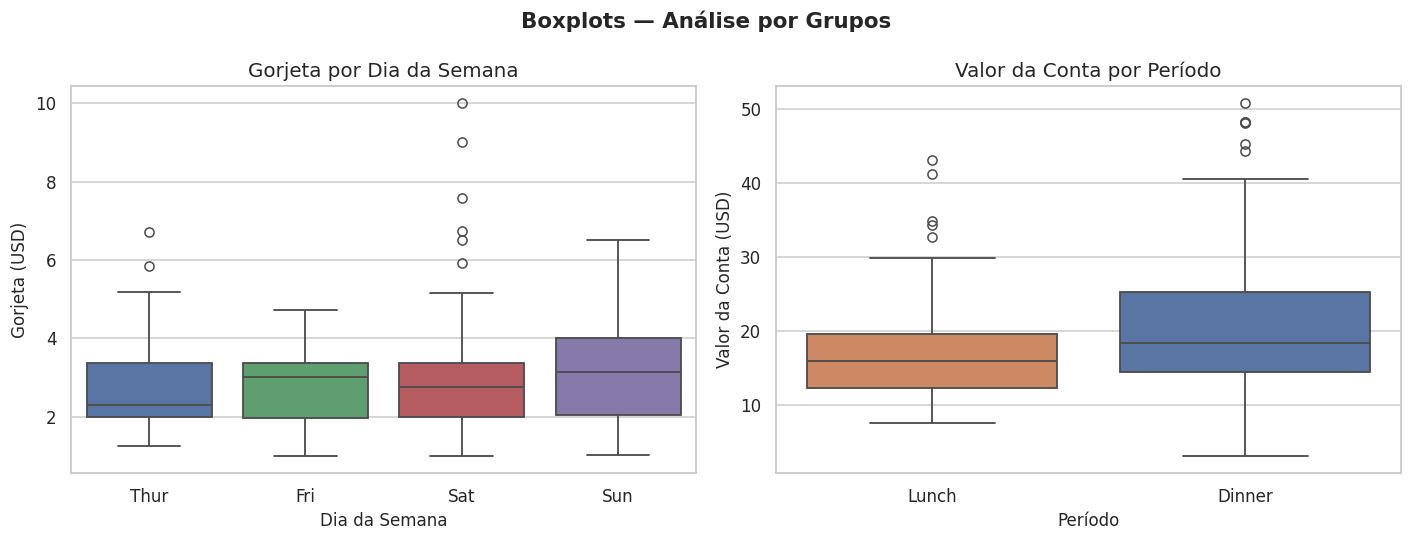

In [ ]:
ordem_dias = ['Thur', 'Fri', 'Sat', 'Sun']
paleta     = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot: gorjeta por dia
sns.boxplot(
    data=df, x='day', y='tip',
    order=ordem_dias, palette=paleta,
    ax=axes[0], linewidth=1.2
)
axes[0].set_title('Gorjeta por Dia da Semana')
axes[0].set_xlabel('Dia da Semana')
axes[0].set_ylabel('Gorjeta (USD)')

# Boxplot: valor da conta por período
sns.boxplot(
    data=df, x='time', y='total_bill',
    palette=['#DD8452', '#4C72B0'],
    ax=axes[1], linewidth=1.2
)
axes[1].set_title('Valor da Conta por Período')
axes[1].set_xlabel('Período')
axes[1].set_ylabel('Valor da Conta (USD)')

fig.suptitle('Boxplots — Análise por Grupos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

gráfico de dispersão

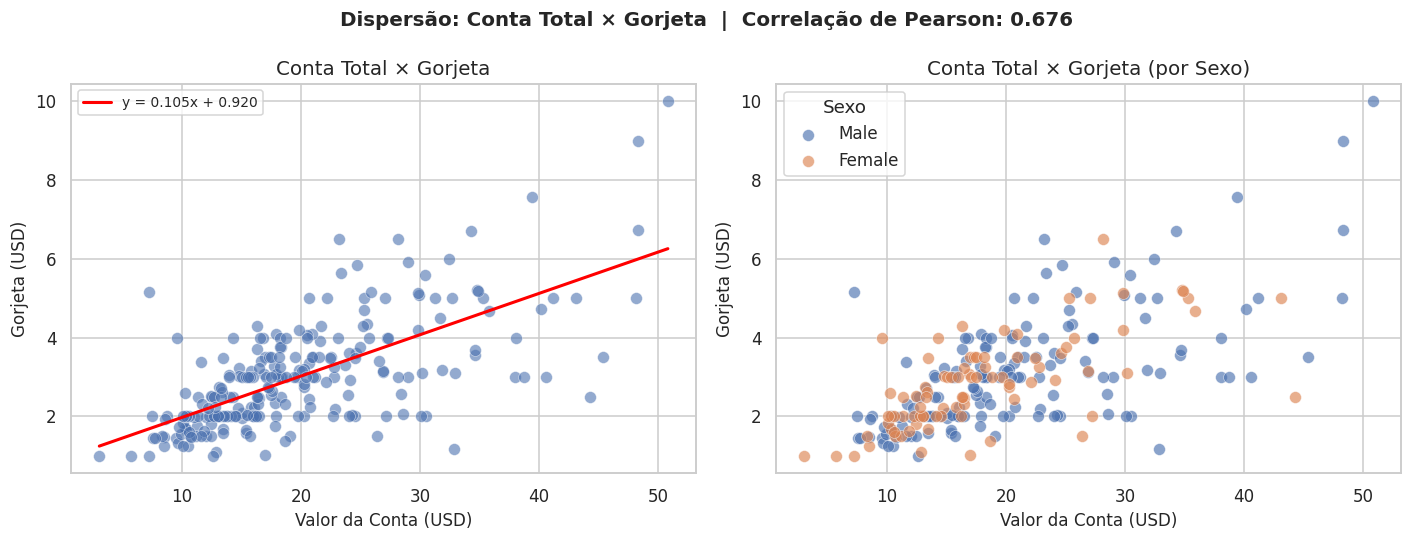


Correlação de Pearson (total_bill × tip): 0.6757


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Dispersão simples com linha de tendência
axes[0].scatter(
    df['total_bill'], df['tip'],
    alpha=0.6, color='#4C72B0', edgecolors='white', linewidths=0.4, s=60
)
# Linha de tendência
m, b = np.polyfit(df['total_bill'], df['tip'], 1)
x_line = np.linspace(df['total_bill'].min(), df['total_bill'].max(), 100)
axes[0].plot(x_line, m * x_line + b, color='red', linewidth=2, label=f'y = {m:.3f}x + {b:.3f}')
axes[0].set_title('Conta Total × Gorjeta')
axes[0].set_xlabel('Valor da Conta (USD)')
axes[0].set_ylabel('Gorjeta (USD)')
axes[0].legend(fontsize=9)

# Dispersão colorida por sexo
cores = {'Male': '#4C72B0', 'Female': '#DD8452'}
for sexo, grupo in df.groupby('sex'):
    axes[1].scatter(
        grupo['total_bill'], grupo['tip'],
        alpha=0.65, color=cores[sexo],
        edgecolors='white', linewidths=0.4,
        s=60, label=sexo
    )
axes[1].set_title('Conta Total × Gorjeta (por Sexo)')
axes[1].set_xlabel('Valor da Conta (USD)')
axes[1].set_ylabel('Gorjeta (USD)')
axes[1].legend(title='Sexo')

# Correlação
corr = df['total_bill'].corr(df['tip'])
fig.suptitle(f'Dispersão: Conta Total × Gorjeta  |  Correlação de Pearson: {corr:.3f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nCorrelação de Pearson (total_bill × tip): {corr:.4f}')

gráfico de barras empilhadas

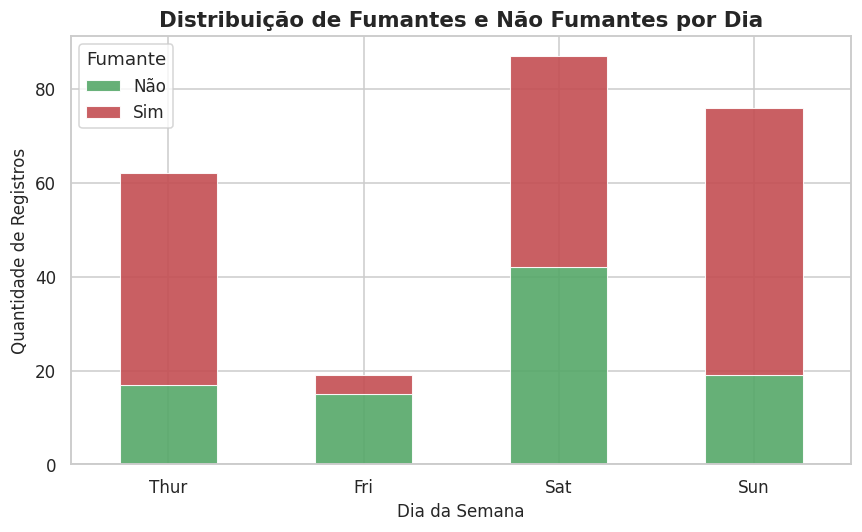


Tabela de suporte:


smoker,Yes,No
day,,
Thur,17,45
Fri,15,4
Sat,42,45
Sun,19,57


In [ ]:
# Tabela cruzada: dia × fumante
ct_dia_fumante = pd.crosstab(
    df['day'], df['smoker']
).reindex(['Thur', 'Fri', 'Sat', 'Sun'])

# Gráfico empilhado
fig, ax = plt.subplots(figsize=(8, 5))

ct_dia_fumante.plot(
    kind='bar', stacked=True,
    color=['#55A868', '#C44E52'],
    edgecolor='white', linewidth=0.7,
    alpha=0.9, ax=ax
)

ax.set_title('Distribuição de Fumantes e Não Fumantes por Dia', fontsize=14, fontweight='bold')
ax.set_xlabel('Dia da Semana')
ax.set_ylabel('Quantidade de Registros')
ax.legend(title='Fumante', labels=['Não', 'Sim'])
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

print('\nTabela de suporte:')
display(ct_dia_fumante)

heatmap

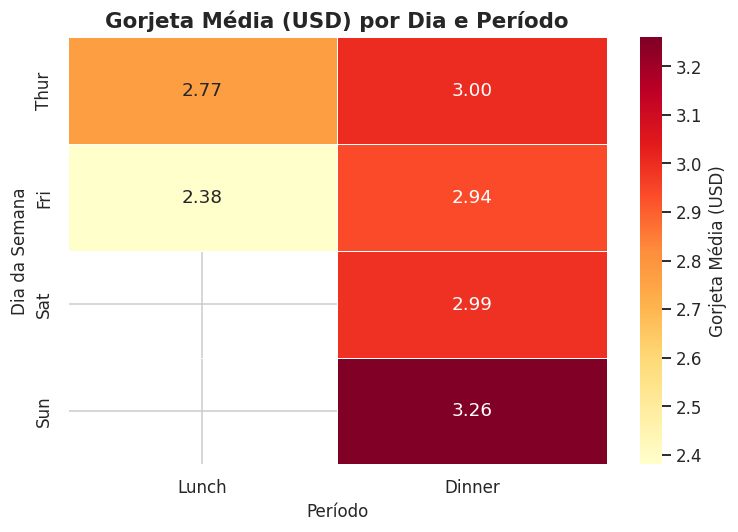


Tabela de suporte (gorjeta média):


time,Lunch,Dinner
day,,
Thur,2.77,3.00
Fri,2.38,2.94
Sat,NaN,2.99
Sun,NaN,3.26


In [ ]:
pivot_heat = df.pivot_table(
    values='tip',
    index='day',
    columns='time',
    aggfunc='mean'
).reindex(['Thur', 'Fri', 'Sat', 'Sun']).round(2)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    pivot_heat,
    annot=True, fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Gorjeta Média (USD)'},
    ax=ax
)
ax.set_title('Gorjeta Média (USD) por Dia e Período', fontsize=14, fontweight='bold')
ax.set_xlabel('Período')
ax.set_ylabel('Dia da Semana')
plt.tight_layout()
plt.show()

print('\nTabela de suporte (gorjeta média):')
display(pivot_heat)

gráfico de linhas

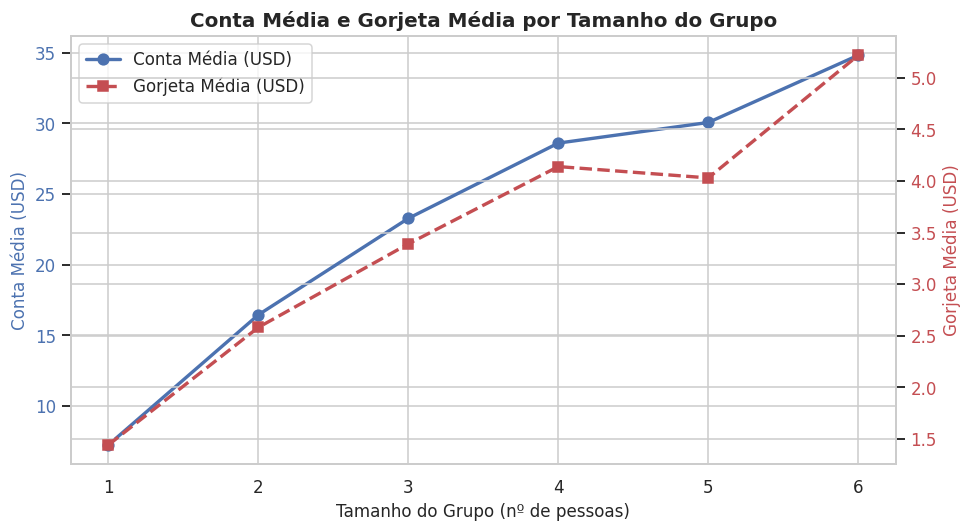


Tabela de suporte:


,total_bill,tip
size,,
1,7.24,1.44
2,16.45,2.58
3,23.28,3.39
4,28.61,4.14
5,30.07,4.03
6,34.83,5.22


In [ ]:
media_por_size = df.groupby('size')[['total_bill', 'tip']].mean().round(2)

fig, ax1 = plt.subplots(figsize=(9, 5))

color_bill = '#4C72B0'
color_tip  = '#C44E52'

ax1.plot(
    media_por_size.index,
    media_por_size['total_bill'],
    color=color_bill, marker='o', linewidth=2.2,
    markersize=7, label='Conta Média (USD)'
)
ax1.set_xlabel('Tamanho do Grupo (nº de pessoas)')
ax1.set_ylabel('Conta Média (USD)', color=color_bill)
ax1.tick_params(axis='y', labelcolor=color_bill)

ax2 = ax1.twinx()
ax2.plot(
    media_por_size.index,
    media_por_size['tip'],
    color=color_tip, marker='s', linewidth=2.2,
    markersize=7, linestyle='--', label='Gorjeta Média (USD)'
)
ax2.set_ylabel('Gorjeta Média (USD)', color=color_tip)
ax2.tick_params(axis='y', labelcolor=color_tip)

# Unir as legendas dos dois eixos
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_title('Conta Média e Gorjeta Média por Tamanho do Grupo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTabela de suporte:')
display(media_por_size)

gráfico de linhas

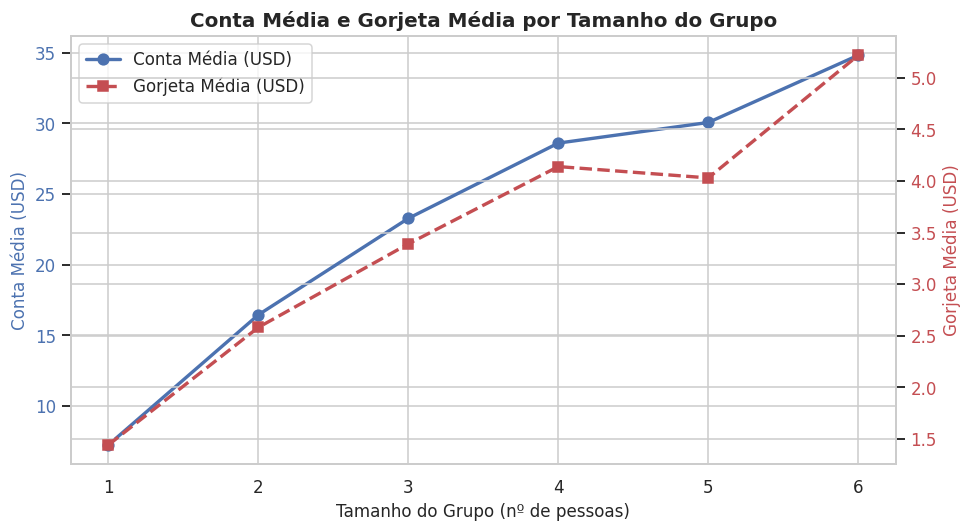


Tabela de suporte:


,total_bill,tip
size,,
1,7.24,1.44
2,16.45,2.58
3,23.28,3.39
4,28.61,4.14
5,30.07,4.03
6,34.83,5.22


In [ ]:
media_por_size = df.groupby('size')[['total_bill', 'tip']].mean().round(2)

fig, ax1 = plt.subplots(figsize=(9, 5))

color_bill = '#4C72B0'
color_tip  = '#C44E52'

ax1.plot(
    media_por_size.index,
    media_por_size['total_bill'],
    color=color_bill, marker='o', linewidth=2.2,
    markersize=7, label='Conta Média (USD)'
)
ax1.set_xlabel('Tamanho do Grupo (nº de pessoas)')
ax1.set_ylabel('Conta Média (USD)', color=color_bill)
ax1.tick_params(axis='y', labelcolor=color_bill)

ax2 = ax1.twinx()
ax2.plot(
    media_por_size.index,
    media_por_size['tip'],
    color=color_tip, marker='s', linewidth=2.2,
    markersize=7, linestyle='--', label='Gorjeta Média (USD)'
)
ax2.set_ylabel('Gorjeta Média (USD)', color=color_tip)
ax2.tick_params(axis='y', labelcolor=color_tip)

# Unir as legendas dos dois eixos
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_title('Conta Média e Gorjeta Média por Tamanho do Grupo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTabela de suporte:')
display(media_por_size)

análise percentual gorjeta

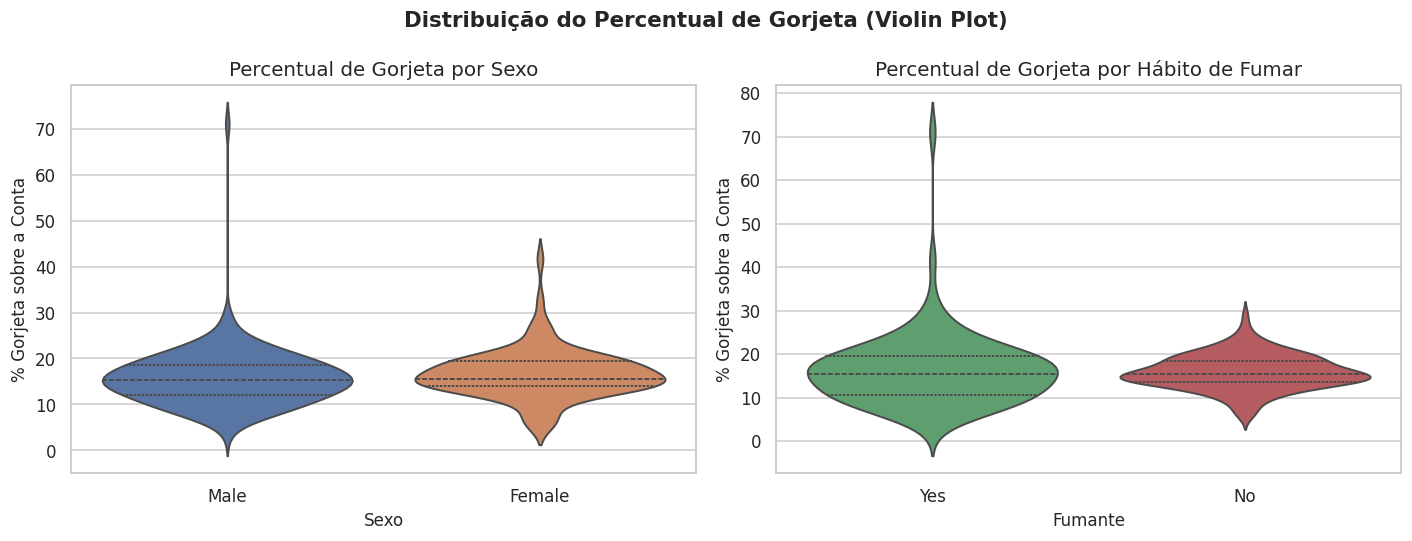

In [ ]:
# Distribuição do percentual de gorjeta por sexo e fumante
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.violinplot(
    data=df, x='sex', y='pct_gorjeta',
    palette=['#4C72B0', '#DD8452'],
    inner='quartile', linewidth=1.3,
    ax=axes[0]
)
axes[0].set_title('Percentual de Gorjeta por Sexo')
axes[0].set_xlabel('Sexo')
axes[0].set_ylabel('% Gorjeta sobre a Conta')

sns.violinplot(
    data=df, x='smoker', y='pct_gorjeta',
    palette=['#55A868', '#C44E52'],
    inner='quartile', linewidth=1.3,
    ax=axes[1]
)
axes[1].set_title('Percentual de Gorjeta por Hábito de Fumar')
axes[1].set_xlabel('Fumante')
axes[1].set_ylabel('% Gorjeta sobre a Conta')

fig.suptitle('Distribuição do Percentual de Gorjeta (Violin Plot)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Tabela resumo do percentual de gorjeta por grupo
print('=== Percentual Médio de Gorjeta por Grupo ===')
resumo_pct = df.groupby(['sex', 'smoker'])['pct_gorjeta'].agg(
    media='mean',
    mediana='median',
    desvio_padrao='std',
    n='count'
).round(2)
display(resumo_pct)

=== Percentual Médio de Gorjeta por Grupo ===


media  mediana  desvio_padrao   n
sex    smoker                                   
Male   Yes     15.28    14.10           9.06  60
       No      16.07    15.76           4.18  97
Female Yes     18.21    17.39           7.16  33
       No      15.69    14.97           3.64  54

## Conclusões

A análise descritiva do dataset tips revelou os seguintes pontos principais:

###  Frequência e Distribuição

- O **sábado** foi o dia com mais atendimentos (87 registros), seguido pelo domingo (76). Quinta-feira e sexta-feira tiveram menor movimento.
- A maioria dos pagantes é do sexo **masculino** (~64%), e o jantar (**Dinner**) é o período predominante (~72%).
- Apenas cerca de **38%** dos clientes são fumantes.

###  Valores de Conta e Gorjeta

- O valor médio da conta é de aproximadamente **\$20**, com mediana de \$17.80 — a distribuição é assimétrica à direita.
- A gorjeta média gira em torno de **\$3.00** (mediana \$2.90), representando cerca de **16%** do valor da conta.
- Há forte **correlação positiva** entre o valor da conta e a gorjeta (Pearson ≈ 0.68): contas maiores tendem a gerar gorjetas maiores.

###  Padrões por Grupo

- Contas do **jantar** são significativamente maiores do que as do almoço — mediana superior em cerca de \$6.
- Grupos maiores tendem a ter contas e gorjetas absolutas maiores, mas o **percentual de gorjeta** se mantém relativamente estável.
- Fumantes apresentam ligeira maior variabilidade no percentual de gorjeta em relação a não fumantes.

###  Considerações Finais

A abordagem descritiva com tabelas de frequência, cruzadas e gráficos variados permite extrair insights valiosos antes de qualquer modelagem preditiva. As análises realizadas nesta etapa seriam insumos fundamentais para um modelo de previsão de gorjeta ou segmentação de clientes.